# A data term, a shaped penalty, and a bias

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/torchsolve/blob/main/examples/01-regularised_solve.ipynb)

The solver takes any number of terms of the form $\lambda \|Rx - c\|^2$. $R$
defaults to the identity, which pulls towards $c$; $c$ defaults to zero, which
pulls towards the origin. A first-difference $R$ penalises roughness instead,
and that is the whole difference between shrinking an answer and smoothing it.

In [1]:
try:
    import torchsolve  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torchsolve", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from torchsolve import Regularizer, conjugate_gradient

SIZE = 200


def noisy_staircase(size=SIZE):
    """A piecewise-constant signal, measured with noise."""
    generator = torch.Generator().manual_seed(0)
    truth = torch.zeros(size, dtype=torch.float64)
    for start, stop, level in ((20, 70, 1.0), (70, 120, -0.5), (140, 180, 0.7)):
        truth[start:stop] = level
    measured = truth + 0.35 * torch.randn(
        size, generator=generator, dtype=torch.float64
    )
    return truth, measured


truth, measured = noisy_staircase()
identity = lambda vector: vector
print("signal", tuple(truth.shape))

signal (200,)


## Shaping the penalty

With no penalty the least-squares answer to an identity operator is the data
itself, noise included. A first-difference operator penalises the difference
between neighbours rather than the values, so it flattens the noise and leaves
the steps.

In [3]:
difference = torch.diff(torch.eye(SIZE, dtype=torch.float64), dim=0)

plain = conjugate_gradient(identity, measured, max_iter=200, rtol=1e-12).solution
smoothed = conjugate_gradient(
    identity,
    measured,
    regularizers=[
        Regularizer(
            8.0,
            operator=lambda vector: difference @ vector,
            adjoint=lambda vector: difference.T @ vector,
        )
    ],
    max_iter=400,
    rtol=1e-12,
).solution

error = lambda estimate: (estimate - truth).norm().item() / truth.norm().item()
print(
    f"relative error: measured {error(measured):.3f}, "
    f"unregularised {error(plain):.3f}, smoothed {error(smoothed):.3f}"
)

relative error: measured 0.544, unregularised 0.544, smoothed 0.277


## What the bias moves

A bias relocates what the term pulls towards. With none it pulls to the
origin, which shrinks the answer; with one it pulls to that instead, at the
same weight.

In [4]:
prior = torch.full((SIZE,), 2.0, dtype=torch.float64)
shrunk = conjugate_gradient(
    identity, measured, regularizers=[Regularizer(4.0)], max_iter=200, rtol=1e-12
).solution
anchored = conjugate_gradient(
    identity,
    measured,
    regularizers=[Regularizer(4.0, bias=prior)],
    max_iter=200,
    rtol=1e-12,
).solution
print(
    f"the same weight pulls to zero (mean {shrunk.mean():+.3f}) or to a "
    f"prior of 2.0 (mean {anchored.mean():+.3f})"
)

the same weight pulls to zero (mean +0.051) or to a prior of 2.0 (mean +1.651)


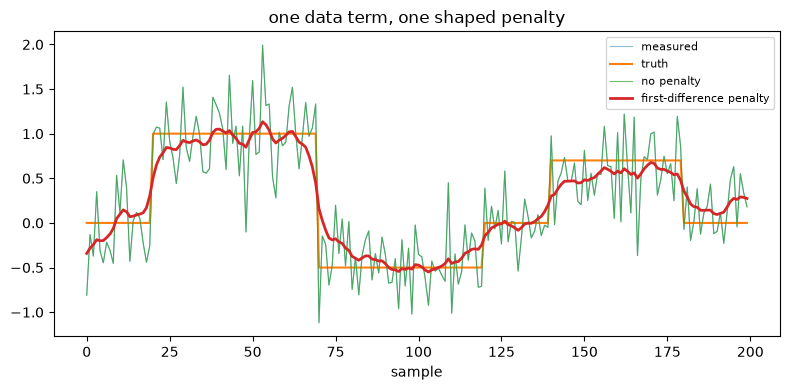

In [5]:
figure, axis = plt.subplots(figsize=(8, 4))
axis.plot(measured, linewidth=0.8, alpha=0.5, label="measured")
axis.plot(truth, linewidth=1.5, label="truth")
axis.plot(plain, linewidth=0.8, alpha=0.7, label="no penalty")
axis.plot(smoothed, linewidth=2.0, label="first-difference penalty")
axis.set_xlabel("sample")
axis.legend(fontsize=8)
axis.set_title("one data term, one shaped penalty")
figure.tight_layout()

figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "regularised_solve.png", dpi=120)